In [1]:
# Import Required Libraries
import qiskit
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

print("Qiskit Version:", qiskit.__version__)
simulator = AerSimulator()

def bell_circuit(state="phi_plus", basis="computational"):
    qc = QuantumCircuit(2, 2)

    # Create Bell state from |00>
    if state == "phi_plus":
        qc.h(0)
        qc.cx(0, 1)

    elif state == "phi_minus":
        qc.h(0)
        qc.z(0)
        qc.cx(0, 1)

    elif state == "psi_plus":
        qc.h(0)
        qc.cx(0, 1)
        qc.x(1)

    elif state == "psi_minus":
        qc.h(0)
        qc.cx(0, 1)
        qc.x(1)
        qc.z(0)

    else:
        raise ValueError("Use phi_plus, phi_minus, psi_plus, or psi_minus")

    # Hadamard basis measurement
    if basis == "hadamard":
        qc.h(0)
        qc.h(1)

    qc.measure([0, 1], [0, 1])
    return qc


def run_bell(state, basis="computational", shots=1024):
    qc = bell_circuit(state, basis)
    result = simulator.run(qc, shots=shots).result()
    return qc, result.get_counts()


bell_names = {
    "phi_plus": "|Φ+⟩",
    "phi_minus": "|Φ−⟩",
    "psi_plus": "|Ψ+⟩",
    "psi_minus": "|Ψ−⟩"
}


Qiskit Version: 2.5.1


Circuit for |Φ+>:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

Measurement counts:
{'11': 496, '00': 528}

Only 00 and 11 observed: True
Total shots: 1024


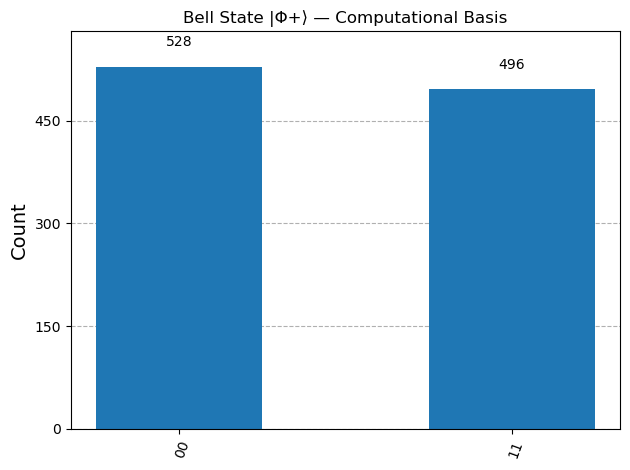

In [2]:
qc, counts = run_bell("phi_plus", basis="computational", shots=1024)

print("Circuit for |Φ+>:")
print(qc)

print("\nMeasurement counts:")
print(counts)

allowed = {"00", "11"}
only_expected = set(counts.keys()).issubset(allowed)

print("\nOnly 00 and 11 observed:", only_expected)
print("Total shots:", sum(counts.values()))

plot_histogram(counts, title="Bell State |Φ+⟩ — Computational Basis")
